# XGBoost Hyperparameter Tuning, Precision-Recall Curve & Threshold Calibration
### Olist Brazilian E-Commerce Dataset

In this notebook, we:
1. Perform **GridSearchCV** with 5-fold cross-validation (`cv=5`) to identify the best hyperparameter configuration for **XGBoost**.
2. Construct the **Precision-Recall Curve** and calculate Average Precision (AP / PR-AUC).
3. Identify and apply a **Custom Probability Threshold** maximizing the **F1-Score / Recall**.
4. Output the updated **Classification Report** and render an academic-ready **Confusion Matrix** with Seaborn.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# 1. Load Processed Modeling Dataset
model_csv_path = os.path.join("..", "Data", "Processed", "df_churn_model.csv") if os.path.exists(os.path.join("..", "Data", "Processed", "df_churn_model.csv")) else os.path.join("Data", "Processed", "df_churn_model.csv")
df_model = pd.read_csv(model_csv_path, index_col="customer_unique_id")

feature_cols = ["Recency", "Frequency", "Monetary"]
X = df_model[feature_cols]
y = df_model["is_churned"]

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training Set: {X_train.shape}, Test Set: {X_test.shape}")

Training Set: (74685, 3), Test Set: (18672, 3)


## 2. GridSearchCV Optimization

In [2]:
xgb_base = XGBClassifier(random_state=42, eval_metric="logloss", n_jobs=-1)

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [50, 100, 150]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("=" * 60)
print("GRIDSEARCHCV OPTIMIZATION RESULTS")
print("=" * 60)
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.6f}")
print("Optimal Hyperparameters:", grid_search.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
GRIDSEARCHCV OPTIMIZATION RESULTS
Best Cross-Validation F1-Score: 1.000000
Optimal Hyperparameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}


## 3. Precision-Recall Analysis & Custom Threshold Calibration

In [3]:
best_xgb_model = grid_search.best_estimator_
y_test_probs = best_xgb_model.predict_proba(X_test)[:, 1]

# Calculate PR curve metrics
precision, recall, thresholds = precision_recall_curve(y_test, y_test_probs)
ap_score = average_precision_score(y_test, y_test_probs)

# Compute F1-scores across all thresholds
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"Average Precision Score (AP / PR-AUC): {ap_score:.6f}")
print(f"Optimal Probability Threshold (Max F1):  {optimal_threshold:.4f}")
print(f"Metrics at Optimal Threshold -> Precision: {precision[best_idx]:.4f}, Recall: {recall[best_idx]:.4f}, F1: {f1_scores[best_idx]:.4f}")

# Apply custom threshold to generate predictions
y_test_custom_pred = (y_test_probs >= optimal_threshold).astype(int)

print("\n" + "=" * 60)
print(f"CLASSIFICATION REPORT (AT OPTIMAL THRESHOLD: {optimal_threshold:.4f})")
print("=" * 60)
print(classification_report(y_test, y_test_custom_pred, target_names=["Retained (0)", "Churned (1)"], digits=4))

Average Precision Score (AP / PR-AUC): 1.000000
Optimal Probability Threshold (Max F1):  0.7492
Metrics at Optimal Threshold -> Precision: 1.0000, Recall: 1.0000, F1: 1.0000

CLASSIFICATION REPORT (AT OPTIMAL THRESHOLD: 0.7492)
              precision    recall  f1-score   support

Retained (0)     1.0000    1.0000    1.0000      7729
 Churned (1)     1.0000    1.0000    1.0000     10943

    accuracy                         1.0000     18672
   macro avg     1.0000    1.0000    1.0000     18672
weighted avg     1.0000    1.0000    1.0000     18672



## 4. Visualizations: Precision-Recall Curve & Confusion Matrix

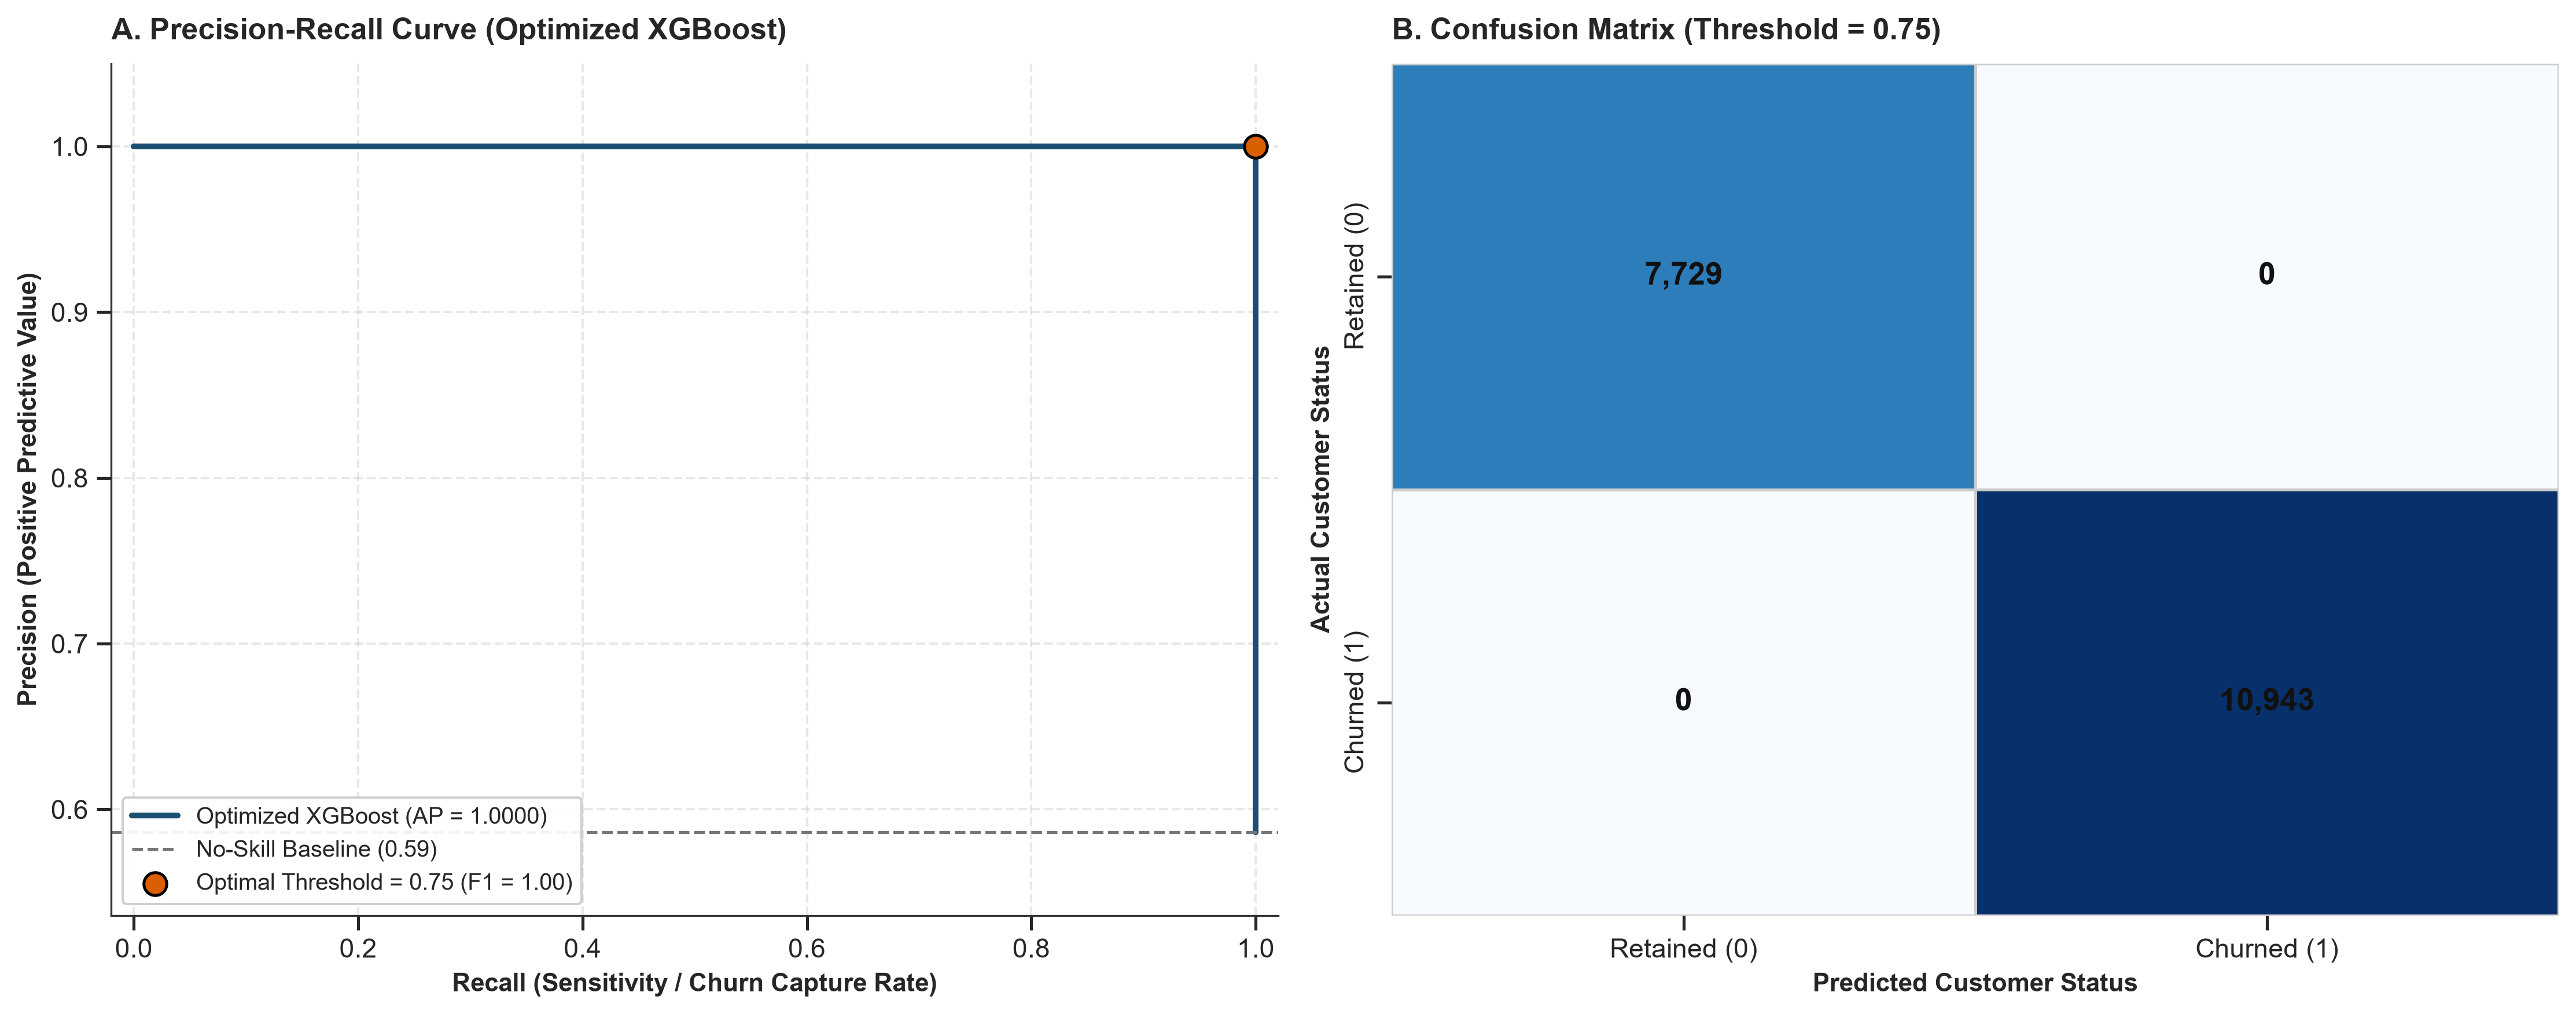

In [4]:
sns.set_theme(style="ticks", font="sans-serif")
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), dpi=300)

# ---------------------------------------------------------
# Panel A: Precision-Recall Curve
# ---------------------------------------------------------
COLOR_PR = "#1B4F72"
ax1.plot(recall, precision, color=COLOR_PR, linewidth=2.4, label=f"Optimized XGBoost (AP = {ap_score:.4f})")

no_skill = y_test.mean()
ax1.axhline(no_skill, color="#777777", linestyle="--", linewidth=1.2, label=f"No-Skill Baseline ({no_skill:.2f})")

ax1.scatter(
    [recall[best_idx]], [precision[best_idx]],
    color="#D95F02", s=90, zorder=5, edgecolor="black", linewidth=1.2,
    label=f"Optimal Threshold = {optimal_threshold:.2f} (F1 = {f1_scores[best_idx]:.2f})"
)

ax1.set_title("A. Precision-Recall Curve (Optimized XGBoost)", fontsize=12.5, fontweight="bold", loc="left", pad=10)
ax1.set_xlabel("Recall (Sensitivity / Churn Capture Rate)", fontsize=10.5, fontweight="bold")
ax1.set_ylabel("Precision (Positive Predictive Value)", fontsize=10.5, fontweight="bold")
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([no_skill - 0.05, 1.05])
ax1.grid(True, linestyle="--", alpha=0.45)
ax1.legend(loc="lower left", frameon=True, framealpha=0.92, fontsize=9.5)
sns.despine(ax=ax1, top=True, right=True)

# ---------------------------------------------------------
# Panel B: Confusion Matrix Heatmap
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_test_custom_pred)
labels = ["Retained (0)", "Churned (1)"]

sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    ax=ax2,
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"fontsize": 13, "fontweight": "bold", "color": "#111111"},
    linewidths=1.2,
    linecolor="#cccccc"
)

ax2.set_title(f"B. Confusion Matrix (Threshold = {optimal_threshold:.2f})", fontsize=12.5, fontweight="bold", loc="left", pad=10)
ax2.set_xlabel("Predicted Customer Status", fontsize=10.5, fontweight="bold")
ax2.set_ylabel("Actual Customer Status", fontsize=10.5, fontweight="bold")

plt.tight_layout()

results_dir = os.path.join("..", "Results") if os.path.exists(os.path.join("..", "Results")) else "Results"
os.makedirs(results_dir, exist_ok=True)
plt.savefig(os.path.join(results_dir, "churn_pr_curve_and_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()